In [1]:
# ! pip install -e ../../savo

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import time
from copy import deepcopy as copy
from scipy import optimize
import torch
np.random.seed(1)
torch.random.manual_seed(1)

import sys
sys.path.append('../')  #for savo import
sys.path.append('../../machineIO/')  #for machineIO import
from savo import savo
from savo.model import GaussianProcess as GP
from savo.optim import adam
from machineIO.util import plot_2D_projection, dictClass
from machineIO.objFunc import SingleTaskObjectiveFunction
from machineIO.VM import VirtualMachineIO
from machineIO import Evaluator

Failed to import 'epics'
Failed to import 'phantasy'


In [3]:
ndim = 2
budget = 100
model_train_budget = 200
ninit = 4  # number of initial ES steps to collect data for surrogate model training
noise =0.0 # 1e-3
max_dx = 2e-2
lr = 0.5
gain_scale_ES = 100

In [4]:
control_CSETs = [f'X{i}:I_CSET' for i in range(ndim)]
control_RDs   = [f'X{i}:I_RD'   for i in range(ndim)]
control_min   = -np.ones(ndim)
control_max   =  np.ones(ndim)
control_maxstep = max_dx*np.ones(ndim)
control_tols  = 1e-3*(control_max-control_min)
monitor_RDs   = [f'Y{i}:I_RD' for i in range(1)]

objective_PVs = monitor_RDs
composite_objective_name = 'rosenbrock'

# obj_func

In [5]:
# def rastrigin(x, noise=0.0):
#     x = torch.as_tensor(x)
#     d = x.shape[-1]
#     y = torch.sum(x**2 - torch.cos(2*np.pi*x), dim=-1) / d + 1
#     return 1 - y + torch.randn_like(y) * noise


def rosenbrock(x, noise=0.0):
    x = torch.as_tensor(x)
    a = 1
    b = 100
    d = x.shape[-1]
    x1 = x[..., :-1]  # x_i (all but last element)
    x2 = x[..., 1:]   # x_{i+1} (all but first element)
    y = torch.sum((a - x1)**2 + b * (x2 - x1**2)**2, dim=-1)/(100*d)
    return 1 - y + torch.randn_like(y) * noise


In [6]:
def composite_objective_func(y):
    return y

In [7]:
vmio = VirtualMachineIO(
    control_CSETs = control_CSETs,
    control_RDs = control_RDs,
    monitor_RDs = monitor_RDs,
    control_min = control_min,
    control_max = control_max,
    fetch_data_time_span = 1.0,
    fun = rosenbrock,
)

In [8]:
# random initial point far from optimum
# y = 1
# while y>0:
#     control_init = np.random.rand(ndim)*(control_max-control_min)+control_min
#     vmio.x = control_init
#     ret, df = vmio.get_df(monitor_RDs)
#     y = rosenbrock(df.values).mean()

control_init = -0.45*np.ones(ndim)
vmio.x = control_init
ret, df = vmio.get_df(monitor_RDs)
y = rosenbrock(df.values).mean()

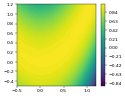

In [9]:
grid = np.linspace(-0.5,1.2,256)
x1,x2 = np.meshgrid(grid,grid)
xgrid = np.vstack((x1.flatten(), x2.flatten())).T
ygrid = rosenbrock(xgrid,noise=0)
def plot_contour(fig,ax):
    cs = ax.tricontourf(xgrid[:,0],xgrid[:,1],ygrid,levels=64)
    fig.colorbar(cs,ax=ax)
fig,ax = plt.subplots(figsize=(4,3.3),dpi=32)
plot_contour(fig,ax)

In [10]:
obj_func = SingleTaskObjectiveFunction(
    objective_PVs = monitor_RDs,
    composite_objective_name = composite_objective_name,
    custom_function = composite_objective_func,
    objective_goal = None, 
    objective_weight = None,
    objective_tolerance = None,
)

In [11]:
evaluator = Evaluator(
    machineIO = vmio,
    control_CSETs = control_CSETs,
    control_RDs = control_RDs,
    control_tols = control_tols,
    monitor_RDs = monitor_RDs,
    df_manipulators = [obj_func.calculate_objectives_from_df],
)

In [ ]:
def plot_hist(history,eval_hist_mean):
    fig, ax = plt.subplots(1,3,figsize=(11*1.5,3*1.5),dpi=96)
    xaxis = np.arange(len(history['y']))
    ax[0].plot(xaxis, history['y'])
    ax[0].set_xlabel('epoch');
    ax[0].set_ylabel('objective');
    ax[1].plot(xaxis, history['cpu_time'])
    ax[1].set_xlabel('epoch');
    ax[1].set_ylabel('cpu_time');
    plot_contour(fig,ax[2])
    ax[2].plot(eval_hist_mean['X0:I_RD'],eval_hist_mean['X1:I_RD'],'k',lw=1)
    ax[2].scatter(eval_hist_mean['X0:I_RD'],eval_hist_mean['X1:I_RD'],s=8,c='k')
    start_x = eval_hist_mean['X0:I_RD'][0]
    start_y = eval_hist_mean['X1:I_RD'][0]
    end_x = eval_hist_mean['X0:I_RD'][-1]
    end_y = eval_hist_mean['X1:I_RD'][-1]
    ax[2].plot(start_x, start_y, 'g+', markersize=4, label='Start Point') # 'go' for green circle
    ax[2].plot(end_x, end_y, 'r*', markersize=4, label='End Point') # 'rs' for red square
    ax[2].set_xlabel('X0:I_RD')
    ax[2].set_ylabel('X1:I_RD')
    ax[2].set_title('Optimization Path')
    ax[2].legend() # Show the labels
    fig.tight_layout()

# NM

In [13]:
import numpy as np
from scipy.optimize import minimize

def optimize_with_nelder_mead(savo, delta=0.002*max_dx, max_evals=budget):
    x0 = savo.x
    n = len(x0)

    # Create initial simplex: first vertex is x0,
    # others are x0 + delta along each dimension
    initial_simplex = [x0]
    for i in range(n):
        vertex = np.array(x0, copy=True)
        vertex[i] += delta
        initial_simplex.append(vertex)
    initial_simplex = np.array(initial_simplex)

    def loss_fn(x):
        return savo.evaluate(x)

    result = minimize(
        loss_fn,
        x0,
        method='Nelder-Mead',
        options={
            'initial_simplex': initial_simplex,
            'maxfev': max_evals,
        }
    )
    return result

In [14]:
df,ramp = evaluator._set_and_read(control_init)
evaluator.clear_history()
sv = savo(control_CSETs, control_RDs, control_min, control_max, control_maxstep, objective_PVs, composite_objective_name, evaluator)
result = optimize_with_nelder_mead(sv,delta=0.1,max_evals=budget)

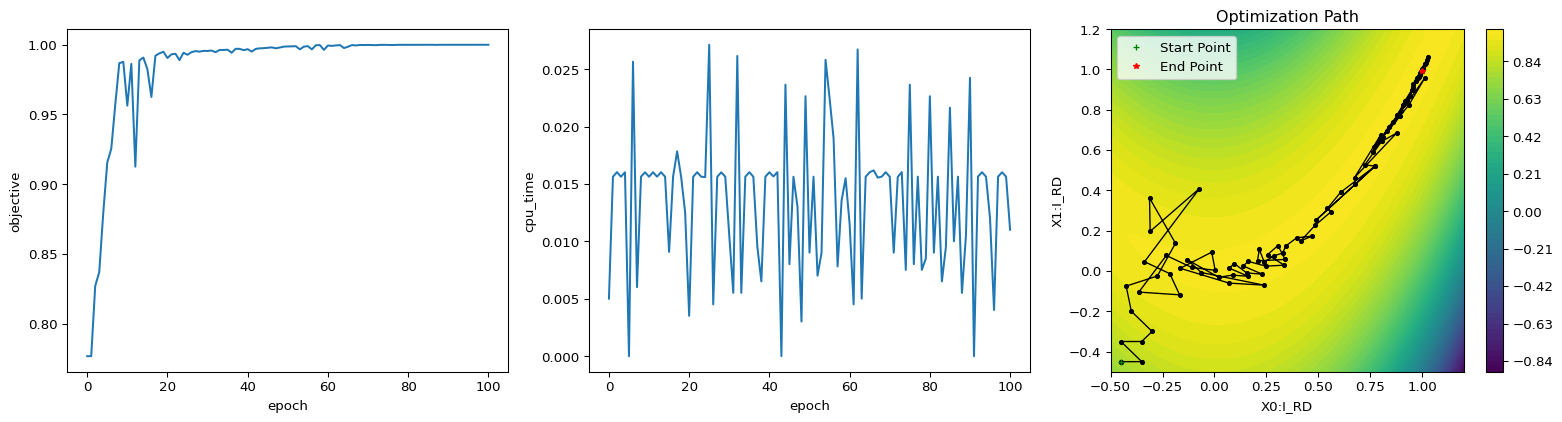

In [15]:
plot_hist(sv.history,sv.evaluator.get_history()['mean'])

In [16]:
svNM = copy(sv.history)
evNM = copy(sv.evaluator.get_history()['mean'])

# ES

In [17]:
df,ramp = evaluator._set_and_read(control_init)
evaluator.clear_history()
sv = savo(control_CSETs, control_RDs, control_min, control_max, control_maxstep, objective_PVs, composite_objective_name, evaluator, gain_scale_ES=gain_scale_ES)
for i in range(budget):
    sv.step(lr=0,lrES=1)

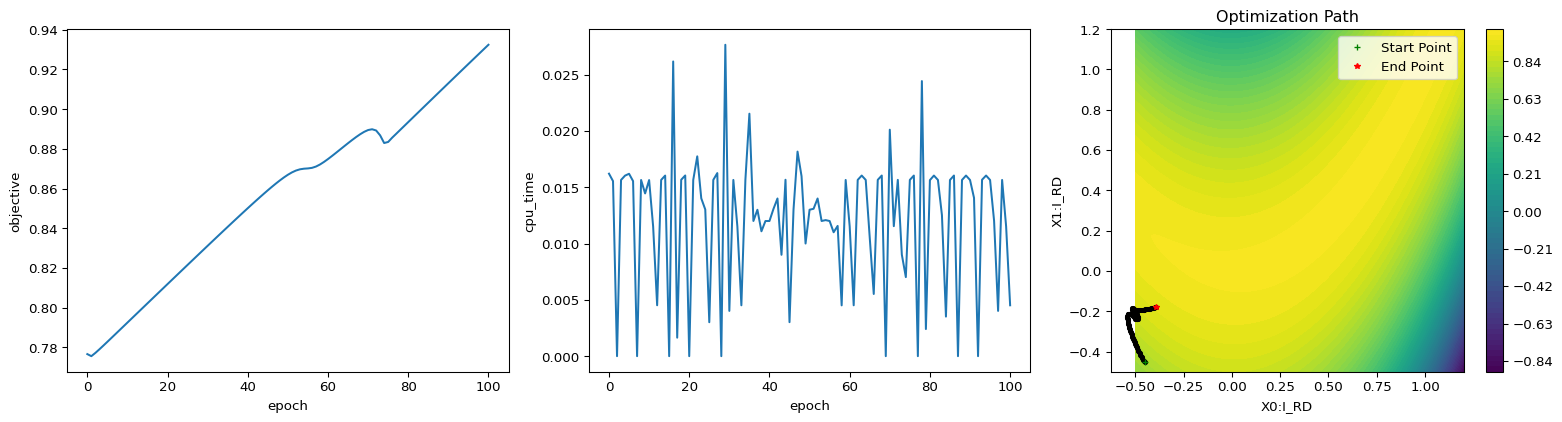

In [18]:
plot_hist(sv.history,sv.evaluator.get_history()['mean'])

In [19]:
svES = copy(sv.history)
evES = copy(sv.evaluator.get_history()['mean'])

# NM vs ES plot

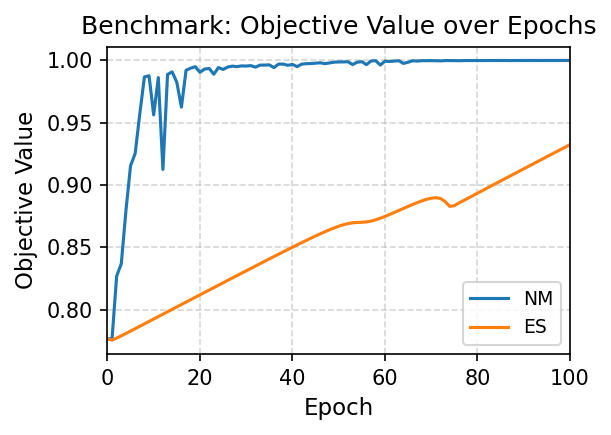

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Optimizer result dictionary
optimizers = {
    'NM': svNM,
    'ES': svES,
}

# Plot settings
plt.figure(figsize=(4, 3), dpi=150)
for name, history in optimizers.items():
    epochs = np.arange(len(history['y']))
    plt.plot(epochs, history['y'], label=name)

# Axis labels and styling
plt.xlabel('Epoch', fontsize=11)
plt.ylabel('Objective Value', fontsize=11)
plt.title('Benchmark: Objective Value over Epochs', fontsize=12)
plt.legend(fontsize=9)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.xlim(0,budget)

# Optional: Use log scale if values vary a lot
# plt.yscale('log')

# plt.show()
plt.savefig('NMvsES.png',dpi=150)

# ES + adamSG

In [21]:
df,ramp = evaluator._set_and_read(control_init)
evaluator.clear_history()
optimizer = adam()
sv = savo(control_CSETs, control_RDs, control_min, control_max, control_maxstep, objective_PVs, composite_objective_name, evaluator, 
          model_train_budget = model_train_budget, optimizer=optimizer, gain_scale_ES=gain_scale_ES)
for i in range(ninit):
    sv.step(lr=0,lrES=1)
for i in range(budget-ninit):
    sv.step(lr=lr,lrES=1)

c:\Users\HWANG\AppData\Local\Programs\Python\Python311\Lib\site-packages\gpytorch\distributions\multivariate_normal.py:319: NumericalWarning: Negative variance values detected. This is likely due to numerical instabilities. Rounding negative variances up to 1e-10.
  warnings.warn(
c:\Users\HWANG\AppData\Local\Programs\Python\Python311\Lib\site-packages\gpytorch\distributions\multivariate_normal.py:319: NumericalWarning: Negative variance values detected. This is likely due to numerical instabilities. Rounding negative variances up to 1e-10.
  warnings.warn(
c:\Users\HWANG\AppData\Local\Programs\Python\Python311\Lib\site-packages\gpytorch\distributions\multivariate_normal.py:319: NumericalWarning: Negative variance values detected. This is likely due to numerical instabilities. Rounding negative variances up to 1e-10.
  warnings.warn(
c:\Users\HWANG\AppData\Local\Programs\Python\Python311\Lib\site-packages\gpytorch\distributions\multivariate_normal.py:319: NumericalWarning: Negative var

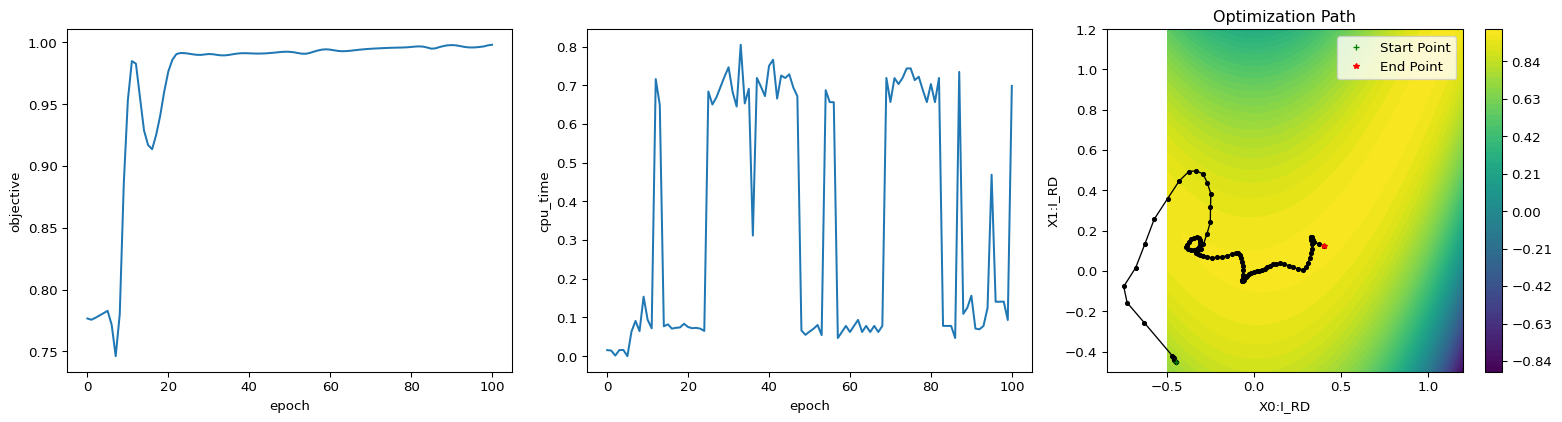

In [22]:
plot_hist(sv.history,sv.evaluator.get_history()['mean'])

In [23]:
svAdamSGES = copy(sv.history)
evAdamSGES = copy(sv.evaluator.get_history()['mean'])

# ES + SG

In [24]:
df,ramp = evaluator._set_and_read(control_init)
evaluator.clear_history()
sv = savo(control_CSETs, control_RDs, control_min, control_max, control_maxstep, objective_PVs, composite_objective_name, evaluator, 
          model_train_budget = model_train_budget, gain_scale_ES=gain_scale_ES)
for i in range(ninit):
    sv.step(lr=0,lrES=1)
for i in range(budget-ninit):
    sv.step(lr=lr,lrES=1)

c:\Users\HWANG\AppData\Local\Programs\Python\Python311\Lib\site-packages\gpytorch\distributions\multivariate_normal.py:319: NumericalWarning: Negative variance values detected. This is likely due to numerical instabilities. Rounding negative variances up to 1e-10.
  warnings.warn(
c:\Users\HWANG\AppData\Local\Programs\Python\Python311\Lib\site-packages\gpytorch\distributions\multivariate_normal.py:319: NumericalWarning: Negative variance values detected. This is likely due to numerical instabilities. Rounding negative variances up to 1e-10.
  warnings.warn(
c:\Users\HWANG\AppData\Local\Programs\Python\Python311\Lib\site-packages\gpytorch\distributions\multivariate_normal.py:319: NumericalWarning: Negative variance values detected. This is likely due to numerical instabilities. Rounding negative variances up to 1e-10.
  warnings.warn(
c:\Users\HWANG\AppData\Local\Programs\Python\Python311\Lib\site-packages\gpytorch\distributions\multivariate_normal.py:319: NumericalWarning: Negative var

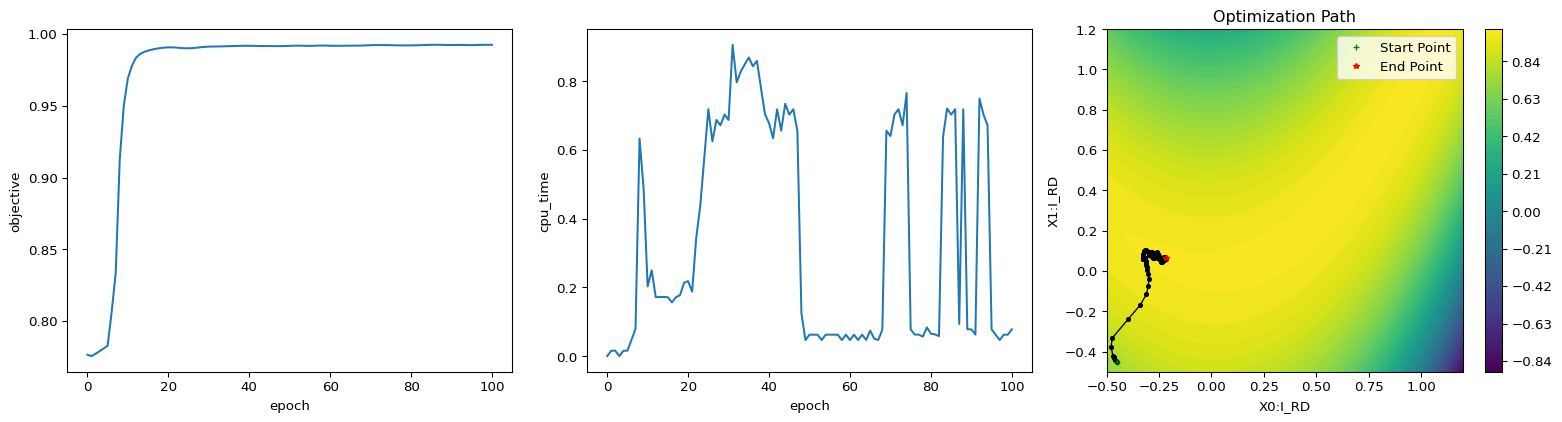

In [25]:
plot_hist(sv.history,sv.evaluator.get_history()['mean'])

In [26]:
svSGES = copy(sv.history)
evSGES = copy(sv.evaluator.get_history()['mean'])

# ES + SG normalized grad

In [27]:
df,ramp = evaluator._set_and_read(control_init)
evaluator.clear_history()
sv = savo(control_CSETs, control_RDs, control_min, control_max, control_maxstep, objective_PVs, composite_objective_name, evaluator, 
          model_train_budget = model_train_budget, gain_scale_ES=gain_scale_ES)
for i in range(ninit):
    sv.step(lr=0,lrES=1)
for i in range(budget-ninit):
    sv.step(lr=lr,lrES=1,normalize_gradient_step=True)

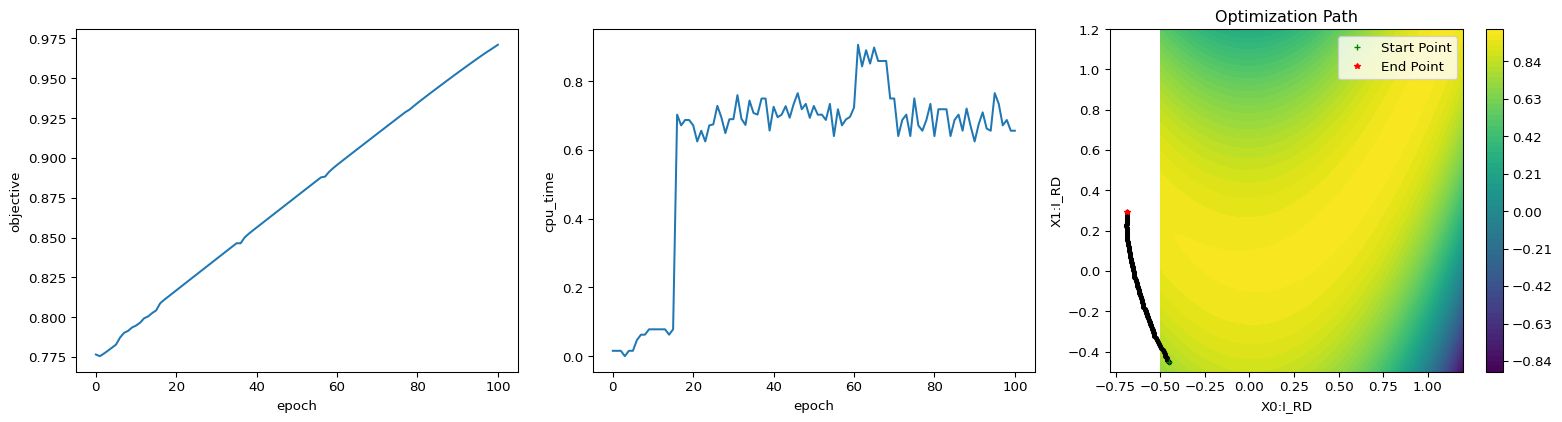

In [28]:
plot_hist(sv.history,sv.evaluator.get_history()['mean'])

# ES + SG penalize_uncertain_gradient

In [29]:
df,ramp = evaluator._set_and_read(control_init)
evaluator.clear_history()
sv = savo(control_CSETs, control_RDs, control_min, control_max, control_maxstep, objective_PVs, composite_objective_name, evaluator, 
          model_train_budget = model_train_budget, gain_scale_ES=gain_scale_ES)
for i in range(ninit):
    sv.step(lr=0,lrES=1)
for i in range(budget-ninit):
    sv.step(lr=lr,lrES=1,penalize_uncertain_gradient=True)

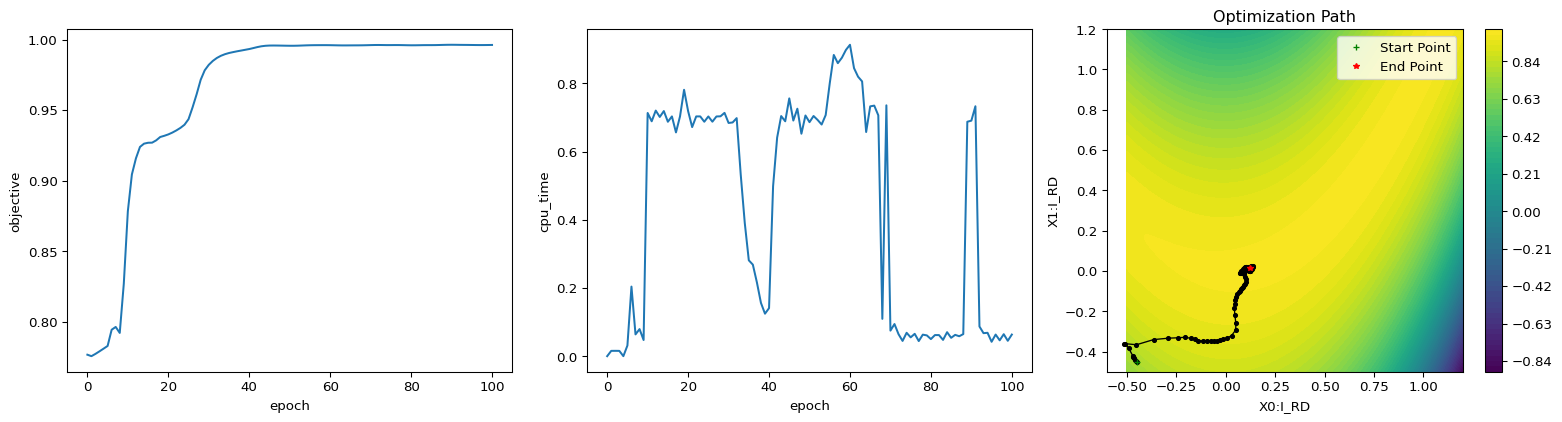

In [30]:
plot_hist(sv.history,sv.evaluator.get_history()['mean'])

In [31]:
svSGESuncertain = copy(sv.history)
evSGESuncertain = copy(sv.evaluator.get_history()['mean'])

# ES + adamSG penalize_uncertain_gradient

In [32]:
df,ramp = evaluator._set_and_read(control_init)
evaluator.clear_history()
sv = savo(control_CSETs, control_RDs, control_min, control_max, control_maxstep, objective_PVs, composite_objective_name, evaluator, 
          model_train_budget = model_train_budget,optimizer = adam(), gain_scale_ES=gain_scale_ES)
for i in range(ninit):
    sv.step(lr=0,lrES=1)
for i in range(budget-ninit):
    sv.step(lr=lr,lrES=1,penalize_uncertain_gradient=True)

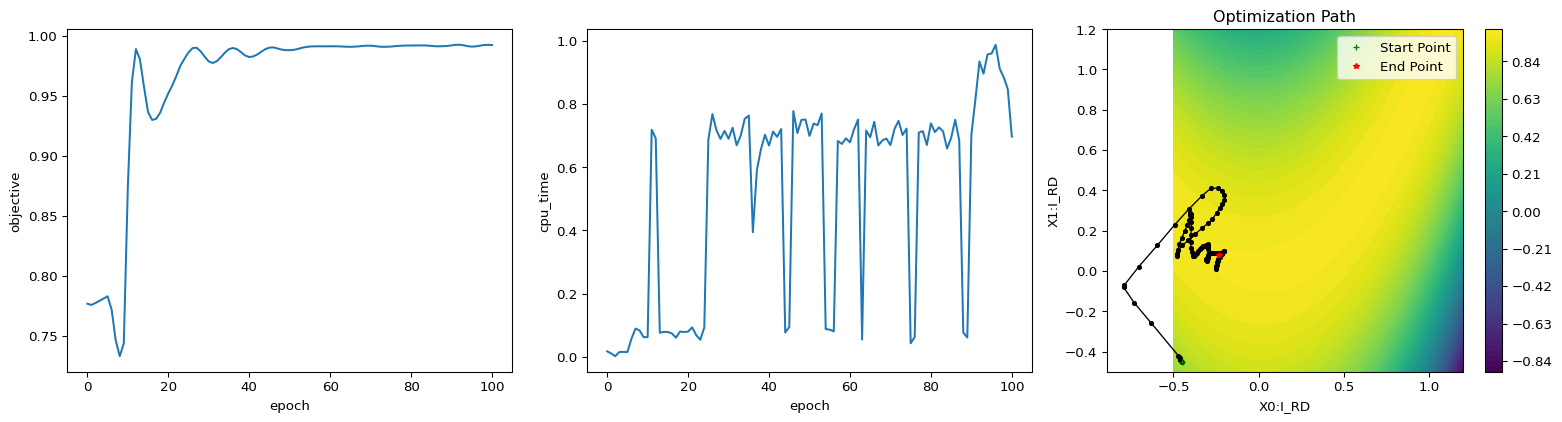

In [33]:
plot_hist(sv.history,sv.evaluator.get_history()['mean'])

In [34]:
svAdamSGESuncertain = copy(sv.history)
evAdamSGESuncertain = copy(sv.evaluator.get_history()['mean'])

# SG wo ES

In [35]:
df,ramp = evaluator._set_and_read(control_init)
evaluator.clear_history()
sv = savo(control_CSETs, control_RDs, control_min, control_max, control_maxstep, objective_PVs, composite_objective_name, evaluator, 
          model_train_budget = model_train_budget, gain_scale_ES=gain_scale_ES)
for i in range(ninit):
    sv.step(lr=0,lrES=1)
for i in range(budget-ninit):
    sv.step(lr=lr,lrES=0)

c:\Users\HWANG\AppData\Local\Programs\Python\Python311\Lib\site-packages\gpytorch\distributions\multivariate_normal.py:319: NumericalWarning: Negative variance values detected. This is likely due to numerical instabilities. Rounding negative variances up to 1e-10.
  warnings.warn(
c:\Users\HWANG\AppData\Local\Programs\Python\Python311\Lib\site-packages\gpytorch\distributions\multivariate_normal.py:319: NumericalWarning: Negative variance values detected. This is likely due to numerical instabilities. Rounding negative variances up to 1e-10.
  warnings.warn(
c:\Users\HWANG\AppData\Local\Programs\Python\Python311\Lib\site-packages\gpytorch\distributions\multivariate_normal.py:319: NumericalWarning: Negative variance values detected. This is likely due to numerical instabilities. Rounding negative variances up to 1e-10.
  warnings.warn(
c:\Users\HWANG\AppData\Local\Programs\Python\Python311\Lib\site-packages\gpytorch\distributions\multivariate_normal.py:319: NumericalWarning: Negative var

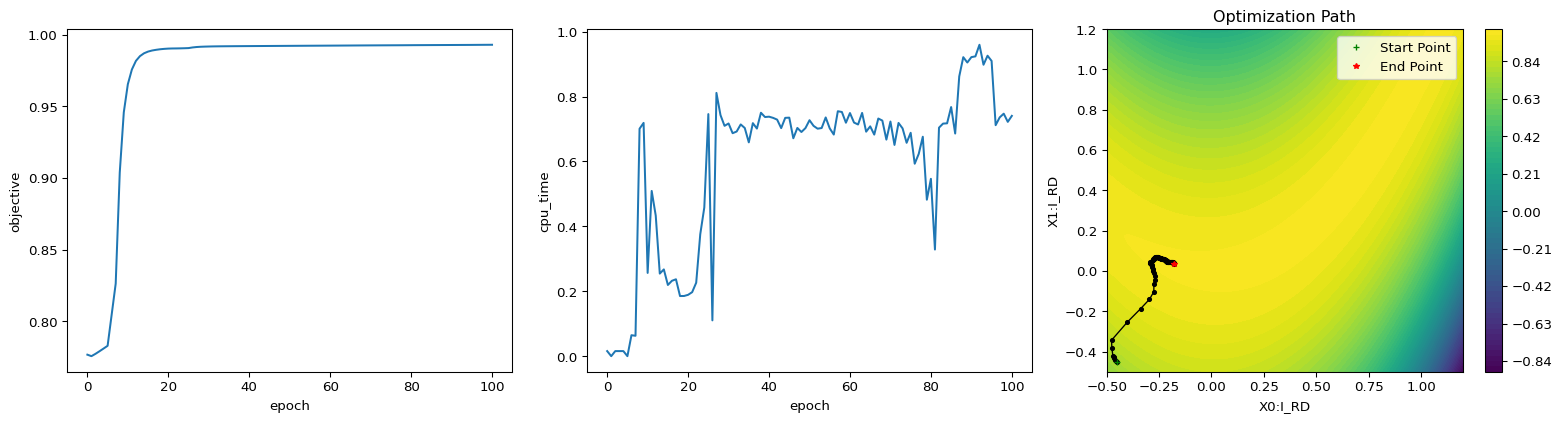

In [36]:
plot_hist(sv.history,sv.evaluator.get_history()['mean'])

In [37]:
svSG = copy(sv.history)
evSG = copy(sv.evaluator.get_history()['mean'])

# SG penalize_uncertain_gradient

In [38]:
df,ramp = evaluator._set_and_read(control_init)
evaluator.clear_history()
sv = savo(control_CSETs, control_RDs, control_min, control_max, control_maxstep, objective_PVs, composite_objective_name, evaluator, 
          model_train_budget = model_train_budget, gain_scale_ES=gain_scale_ES)
for i in range(ninit):
    sv.step(lr=0,lrES=1)
for i in range(budget-ninit):
    sv.step(lr=lr,lrES=0,penalize_uncertain_gradient=True)

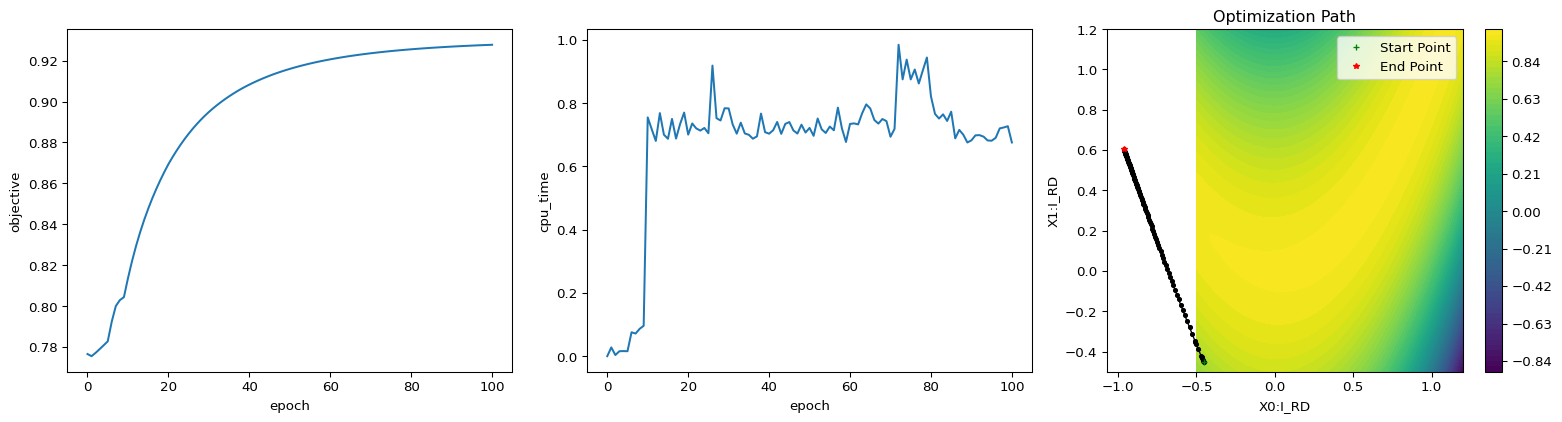

In [39]:
plot_hist(sv.history,sv.evaluator.get_history()['mean'])

In [40]:
svSGuncertain = copy(sv.history)
evSGuncertain = copy(sv.evaluator.get_history()['mean'])

# adamSG wo ES

In [41]:
df,ramp = evaluator._set_and_read(control_init)
evaluator.clear_history()
optimizer = adam()
sv = savo(control_CSETs, control_RDs, control_min, control_max, control_maxstep, objective_PVs, composite_objective_name, evaluator, 
          model_train_budget = model_train_budget, optimizer=optimizer, gain_scale_ES=gain_scale_ES)
for i in range(ninit):
    sv.step(lr=0,lrES=1)
for i in range(budget-ninit):
    sv.step(lr=lr,lrES=0)

c:\Users\HWANG\AppData\Local\Programs\Python\Python311\Lib\site-packages\gpytorch\distributions\multivariate_normal.py:319: NumericalWarning: Negative variance values detected. This is likely due to numerical instabilities. Rounding negative variances up to 1e-10.
  warnings.warn(
c:\Users\HWANG\AppData\Local\Programs\Python\Python311\Lib\site-packages\gpytorch\distributions\multivariate_normal.py:319: NumericalWarning: Negative variance values detected. This is likely due to numerical instabilities. Rounding negative variances up to 1e-10.
  warnings.warn(
c:\Users\HWANG\AppData\Local\Programs\Python\Python311\Lib\site-packages\gpytorch\distributions\multivariate_normal.py:319: NumericalWarning: Negative variance values detected. This is likely due to numerical instabilities. Rounding negative variances up to 1e-10.
  warnings.warn(
c:\Users\HWANG\AppData\Local\Programs\Python\Python311\Lib\site-packages\gpytorch\distributions\multivariate_normal.py:319: NumericalWarning: Negative var

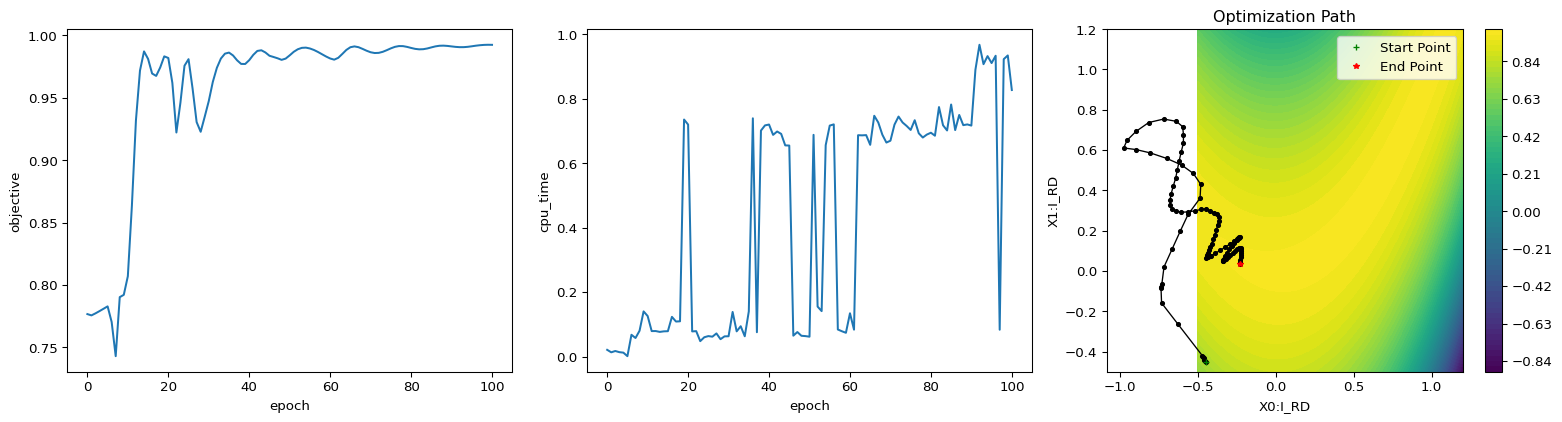

In [42]:
plot_hist(sv.history,sv.evaluator.get_history()['mean'])

In [43]:
svAdamSG = copy(sv.history)
evAdamSG = copy(sv.evaluator.get_history()['mean'])

# adamSG wo ES penalize_uncertain_gradient

In [44]:
df,ramp = evaluator._set_and_read(control_init)
evaluator.clear_history()
optimizer = adam()
sv = savo(control_CSETs, control_RDs, control_min, control_max, control_maxstep, objective_PVs, composite_objective_name, evaluator, 
          model_train_budget = model_train_budget, optimizer=optimizer, gain_scale_ES=gain_scale_ES)
for i in range(ninit):
    sv.step(lr=0,lrES=1)
for i in range(budget-ninit):
    sv.step(lr=lr,lrES=0,penalize_uncertain_gradient=True)

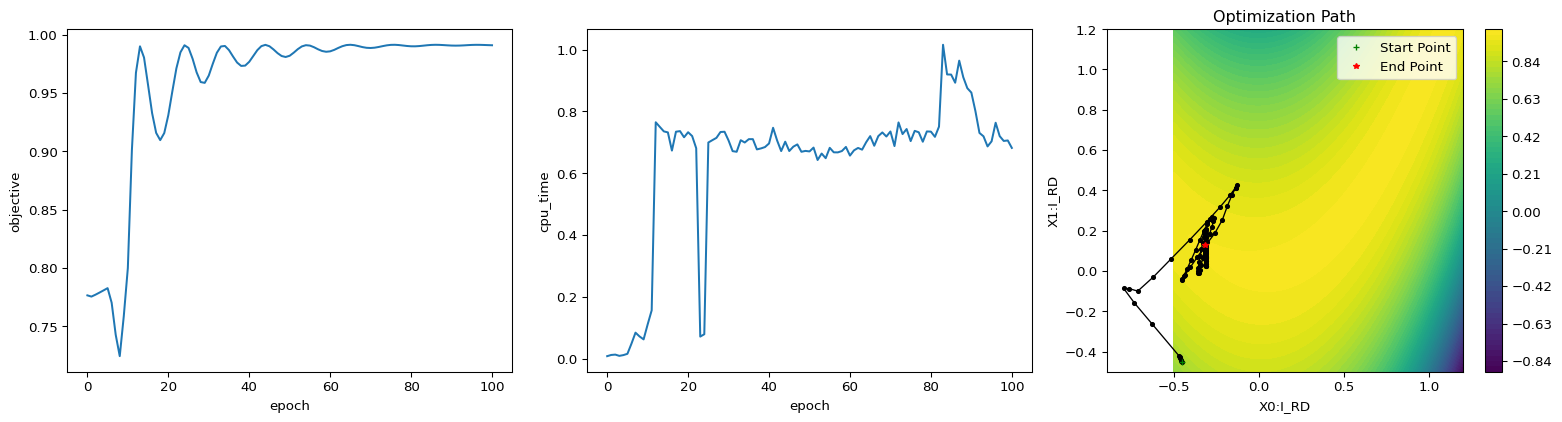

In [45]:
plot_hist(sv.history,sv.evaluator.get_history()['mean'])

In [46]:
svAdamSGuncertain = copy(sv.history)
evAdamSGuncertain = copy(sv.evaluator.get_history()['mean'])

# aggregate

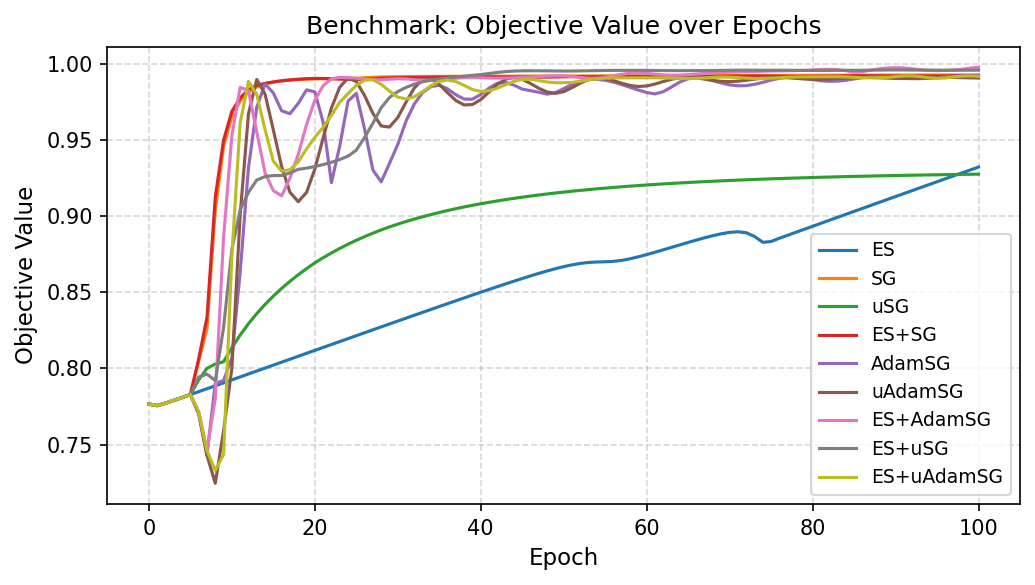

In [47]:
import matplotlib.pyplot as plt
import numpy as np

# Optimizer result dictionary
optimizers = {
    # 'NM': svNM,
    'ES': svES,
    'SG': svSG,
    'uSG': svSGuncertain,
    'ES+SG': svSGES,
    'AdamSG': svAdamSG,
    'uAdamSG': svAdamSGuncertain,
    'ES+AdamSG': svAdamSGES,
    'ES+uSG': svSGESuncertain,
    'ES+uAdamSG': svAdamSGESuncertain
}

# Plot settings
plt.figure(figsize=(7, 4), dpi=150)
for name, history in optimizers.items():
    epochs = np.arange(len(history['y']))
    plt.plot(epochs, history['y'], label=name)

# Axis labels and styling
plt.xlabel('Epoch', fontsize=11)
plt.ylabel('Objective Value', fontsize=11)
plt.title('Benchmark: Objective Value over Epochs', fontsize=12)
plt.legend(fontsize=9)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
# plt.xlim(0,125)

# Optional: Use log scale if values vary a lot
# plt.yscale('log')

# plt.show()
plt.savefig('[50D]benchmark_full.png',dpi=150)

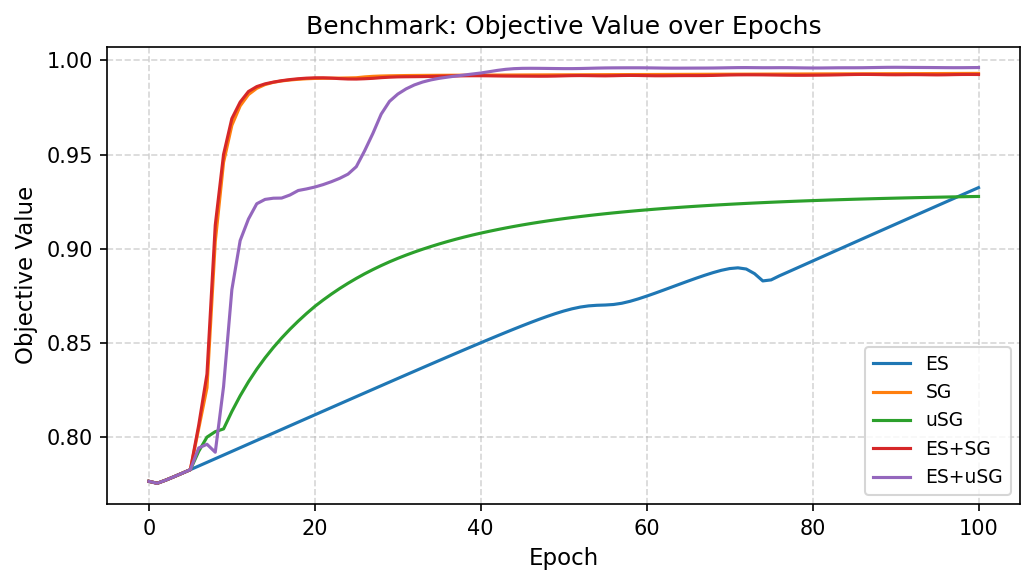

In [48]:
import matplotlib.pyplot as plt
import numpy as np

# Optimizer result dictionary
optimizers = {
    'ES': svES,
    'SG': svSG,
    'uSG': svSGuncertain,
    'ES+SG': svSGES,
    'ES+uSG': svSGESuncertain,
    # 'AdamSG': svAdamSG,
    # 'uAdamSG': svAdamSGuncertain,
    # 'ES+AdamSG': svAdamSGES,
    # 'ES+uAdamSG': svAdamSGESuncertain
}

# Plot settings
plt.figure(figsize=(7, 4), dpi=150)
for name, history in optimizers.items():
    epochs = np.arange(len(history['y']))
    plt.plot(epochs, history['y'], label=name)

# Axis labels and styling
plt.xlabel('Epoch', fontsize=11)
plt.ylabel('Objective Value', fontsize=11)
plt.title('Benchmark: Objective Value over Epochs', fontsize=12)
plt.legend(fontsize=9)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
# plt.xlim(0,125)

# Optional: Use log scale if values vary a lot
# plt.yscale('log')

# plt.show()
plt.savefig('[50D]benchmark_SG.png',dpi=150)

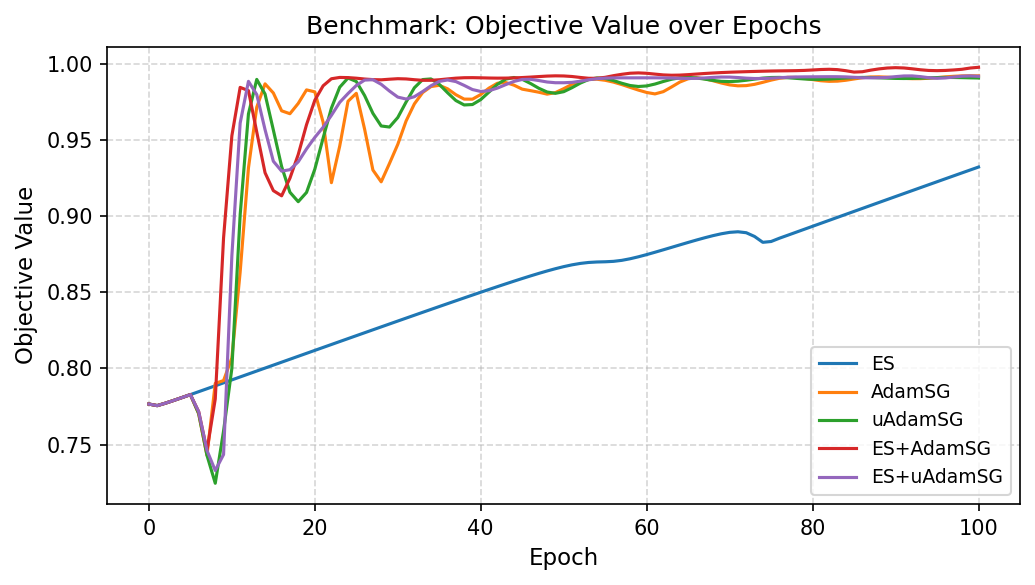

In [49]:
import matplotlib.pyplot as plt
import numpy as np

# Optimizer result dictionary
optimizers = {
    'ES': svES,
    # 'SG': svSG,
    # 'uSG': svSGuncertain,
    # 'ES+SG': svSGES,
    # 'ES+uSG': svSGESuncertain,
    'AdamSG': svAdamSG,
    'uAdamSG': svAdamSGuncertain,
    'ES+AdamSG': svAdamSGES,
    'ES+uAdamSG': svAdamSGESuncertain
}

# Plot settings
plt.figure(figsize=(7, 4), dpi=150)
for name, history in optimizers.items():
    epochs = np.arange(len(history['y']))
    plt.plot(epochs, history['y'], label=name)

# Axis labels and styling
plt.xlabel('Epoch', fontsize=11)
plt.ylabel('Objective Value', fontsize=11)
plt.title('Benchmark: Objective Value over Epochs', fontsize=12)
plt.legend(fontsize=9)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
# plt.xlim(0,125)

# Optional: Use log scale if values vary a lot
# plt.yscale('log')

# plt.show()
plt.savefig('[50D]benchmark_adamSG.png',dpi=150)

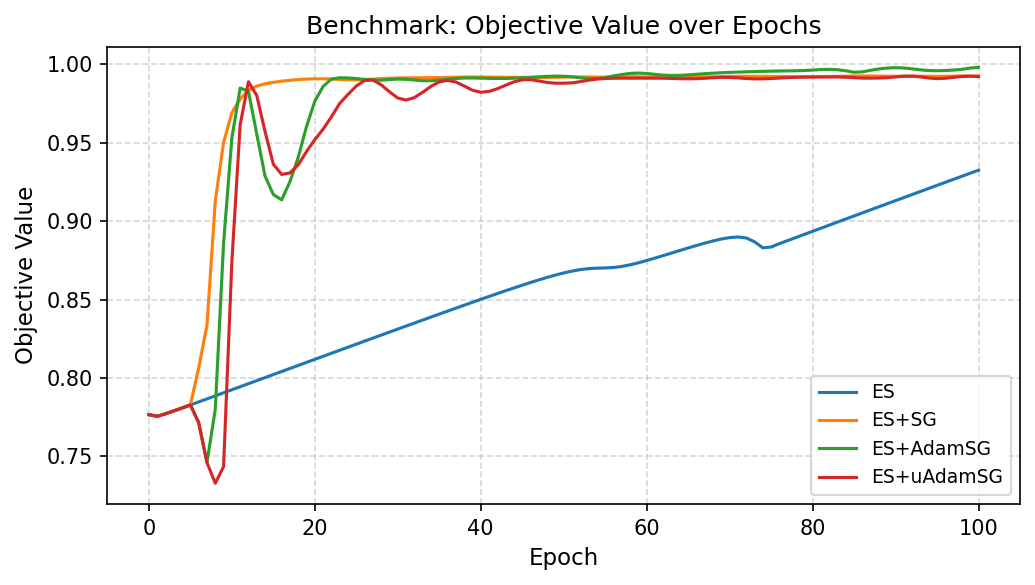

In [50]:
import matplotlib.pyplot as plt
import numpy as np

# Optimizer result dictionary
optimizers = {
    'ES': svES,
    # 'SG': svSG,
    # 'uSG': svSGuncertain,
    'ES+SG': svSGES,
    # 'ES+uSG': svSGESuncertain,
    # 'AdamSG': svAdamSG,
    # 'uAdamSG': svAdamSGuncertain,
    'ES+AdamSG': svAdamSGES,
    'ES+uAdamSG': svAdamSGESuncertain
}

# Plot settings
plt.figure(figsize=(7, 4), dpi=150)
for name, history in optimizers.items():
    epochs = np.arange(len(history['y']))
    plt.plot(epochs, history['y'], label=name)

# Axis labels and styling
plt.xlabel('Epoch', fontsize=11)
plt.ylabel('Objective Value', fontsize=11)
plt.title('Benchmark: Objective Value over Epochs', fontsize=12)
plt.legend(fontsize=9)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
# plt.xlim(0,125)

# Optional: Use log scale if values vary a lot
# plt.yscale('log')

# plt.show()
plt.savefig('[50D]benchmark_brieft.png',dpi=150)

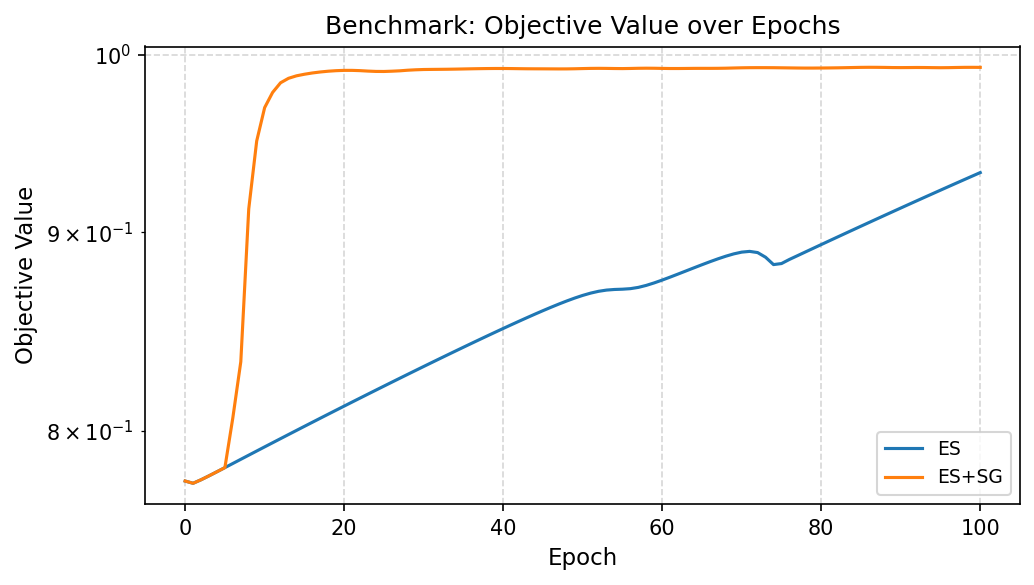

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Optimizer result dictionary
optimizers = {
    'ES': svES,
    # 'SG': svSG,
    # 'uSG': svSGuncertain,
    'ES+SG': svSGES,
    # 'ES+uSG': svSGESuncertain,
    # 'AdamSG': svAdamSG,
    # 'uAdamSG': svAdamSGuncertain,
    # 'ES+AdamSG': svAdamSGES,
    # 'ES+uAdamSG': svAdamSGESuncertain
}

# Plot settings
plt.figure(figsize=(7, 4), dpi=150)
for name, history in optimizers.items():
    epochs = np.arange(len(history['y']))
    plt.plot(epochs, history['y'], label=name)

# Axis labels and styling
plt.xlabel('Epoch', fontsize=11)
plt.ylabel('Objective Value', fontsize=11)
plt.title('Benchmark: Objective Value over Epochs', fontsize=12)
plt.legend(fontsize=9)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
# plt.xlim(0,125)

# Optional: Use log scale if values vary a lot
# plt.yscale('log')

# plt.show()
plt.savefig('[50D]benchmark_ESvsESSG.png',dpi=150)